## Preliminar

In [1]:
import numpy as np


def gauss(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


def constante_en_intervalo(
    x: np.ndarray,
    const: float,
    a: float,
    b: float,
) -> np.ndarray:
    return const * ((a <= x) & (x <= b))


def funcion_constante(z: np.ndarray, const: float) -> np.ndarray:
    return np.full_like(z, const)


def kernel_gaussiano(x: np.ndarray, y: np.ndarray, sigma_K: float) -> np.ndarray:
    norm = (x - y) ** 2
    exp = np.exp(-norm / (2 * sigma_K**2))
    return exp / (sigma_K * np.sqrt(2 * np.pi))


def supply_rate_gaussiano(y: np.ndarray, sigma_in: float, M_in: float) -> np.ndarray:
    exp = np.exp(-(y**2) / (2 * sigma_in**2))
    return M_in * exp / (sigma_in * np.sqrt(2 * np.pi))

In [2]:
from src import Model

consumer_domain = np.array([[-2, 2]])
resource_domain = np.array([[-2, 2]])

## Ejemplo

#### Falla por difusión, positividad

Calculo condicion CFL
hx:  0.013289036544850499
hx^2:  0.00017659849229037207
hx^2/(4*(1 - theta)*eps):  8.829924614518603
dt:  100.0
dt <= hx^2/(4*(1 - theta)*eps):  False


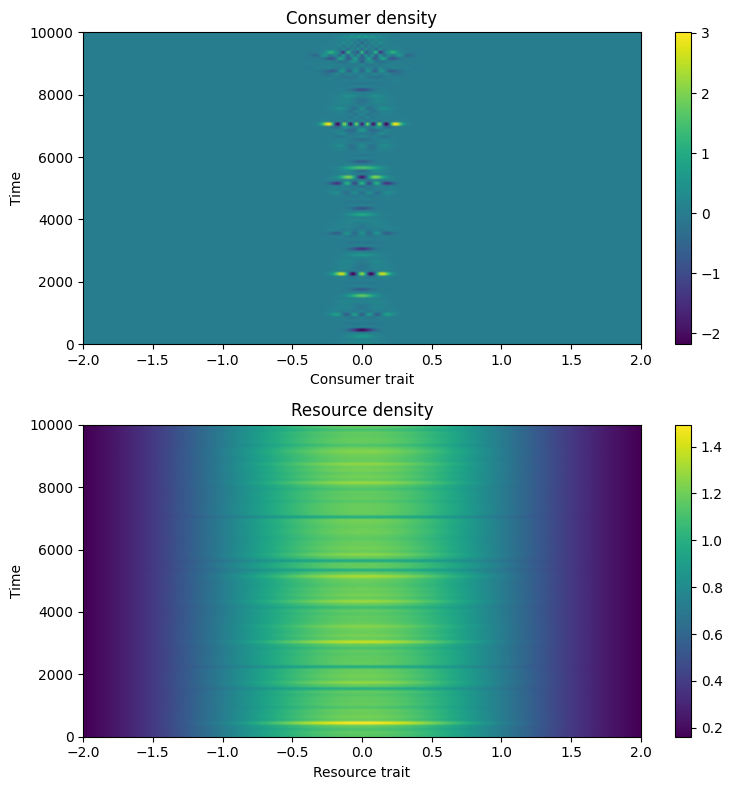

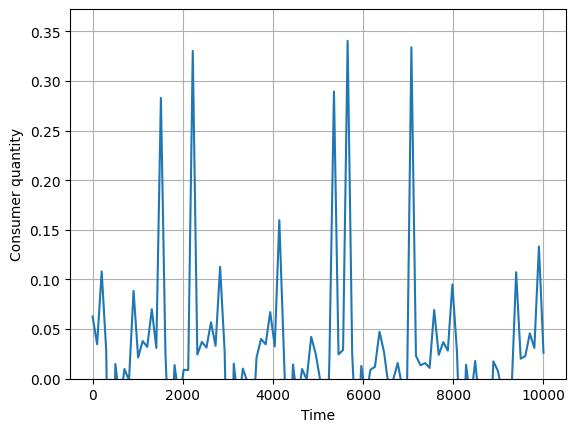

In [24]:
EstudioMortalidad.set_consumer_decay(
    lambda x: funcion_constante(x, const=1.0)
)  # la población prevalece
EstudioMortalidad.set_resource_decay(lambda y: funcion_constante(y, const=1.0))

T = 10000

EstudioMortalidad.solve_by_finite_differences(
    T=T,
    n_t=100,
    n_x=301,
    n_y=301,
    border_type="neumann",
    theta=0.5,
    use_stationary_resource=True,
)

print("Calculo condicion CFL")
print("hx: ", 4/301)
print("hx^2: ", (4/301)**2)
print("hx^2/(4*(1 - theta)*eps): ", (4/301)**2 / (4 * (1 - 0.5) * 0.00001))
print("dt: ", 10000/100)
print("dt <= hx^2/(4*(1 - theta)*eps): ", 10000/100 <= (4/301)**2 / (4 * (1 - 0.5) * 0.00001))

EstudioMortalidad.plot.solution_over_time(plot_type="heatmap")
EstudioMortalidad.plot.consumer_quantity()